# Pronóstico de Generación Solar - Planta "El Paso"

## Creación y análisis del dataset

### Ubicación de la Planta: El Paso, Cesar, Colombia
> **Coordenadas**: 9.785041627157241, -73.7201783147516
> La planta solar **"El Paso"** se encuentra ubicada en el departamento del Cesar, Colombia. Esta región es privilegiada por su alta radiación solar, lo que la hace ideal para la generación de energía fotovoltaica.

### Datos de Generación Real (XM)
Los registros de generación provienen de **XM**, el operador del Sistema Interconectado Nacional (SIN) en Colombia. Representan la telemedida directa instalada en la planta.

| Variable | Columna CSV | Unidad | Descripción |
| :--- | :--- | :--- | :--- |
| **Fecha** | `Fecha` | YYYY-MM-DD | Fecha del reporte de generación. |
| **Recurso** | `Recurso` | Texto | Nombre de la planta (EL PASO). |
| **Generación Horaria** | `0, 1, ..., 23` | kWh | Energía real generada en cada intervalo de una hora. |
| **Versión** | `Version` | Texto | Código de versión del dato reportado. |

El archivo de datos de XM ya existe localmente.
Generando visualizaciones...


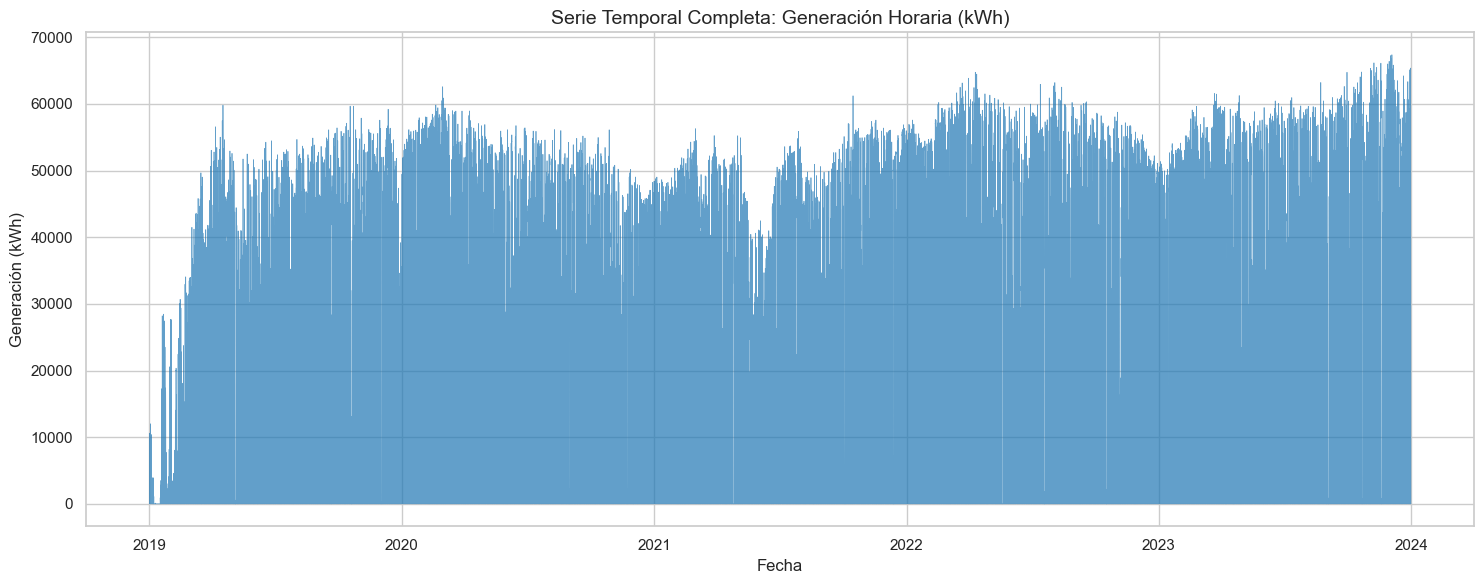

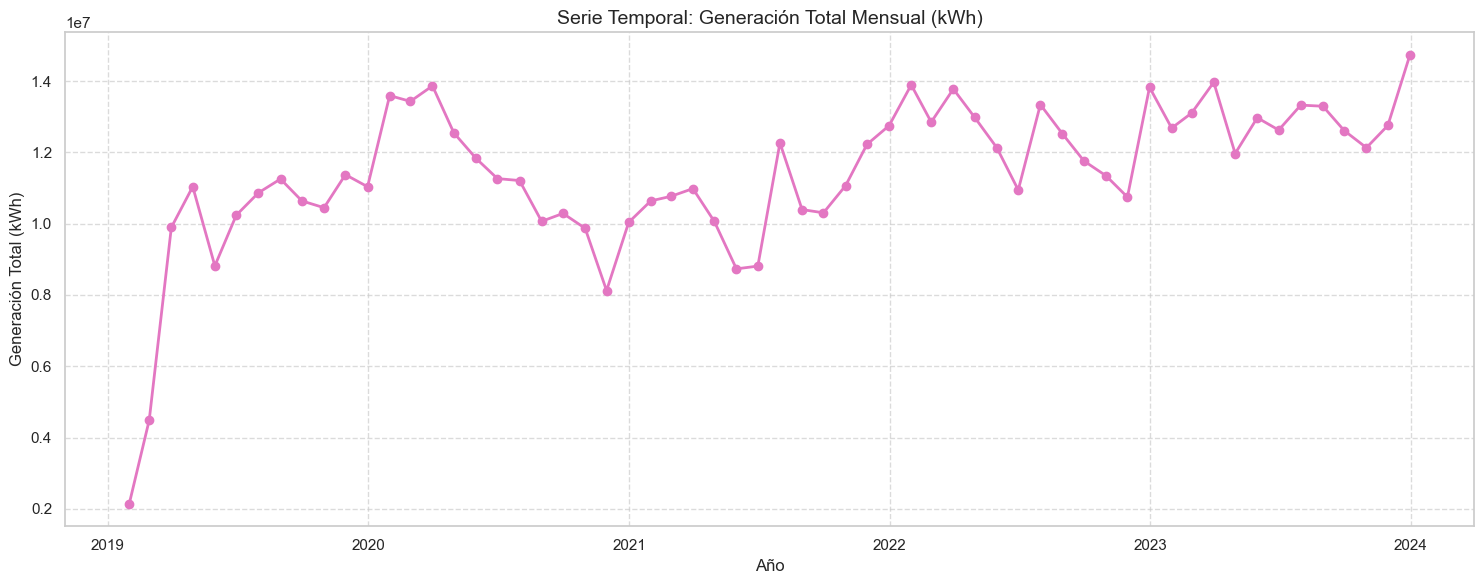

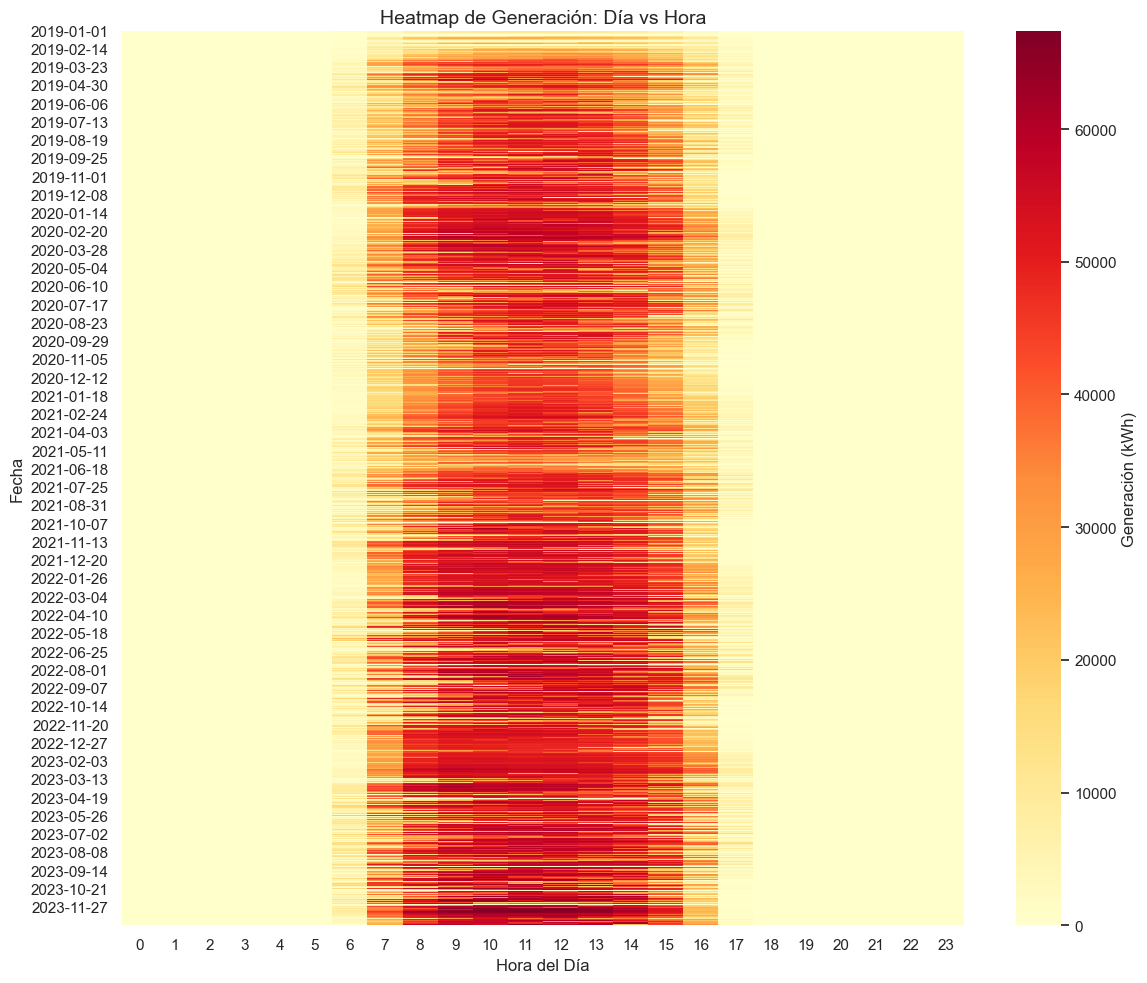

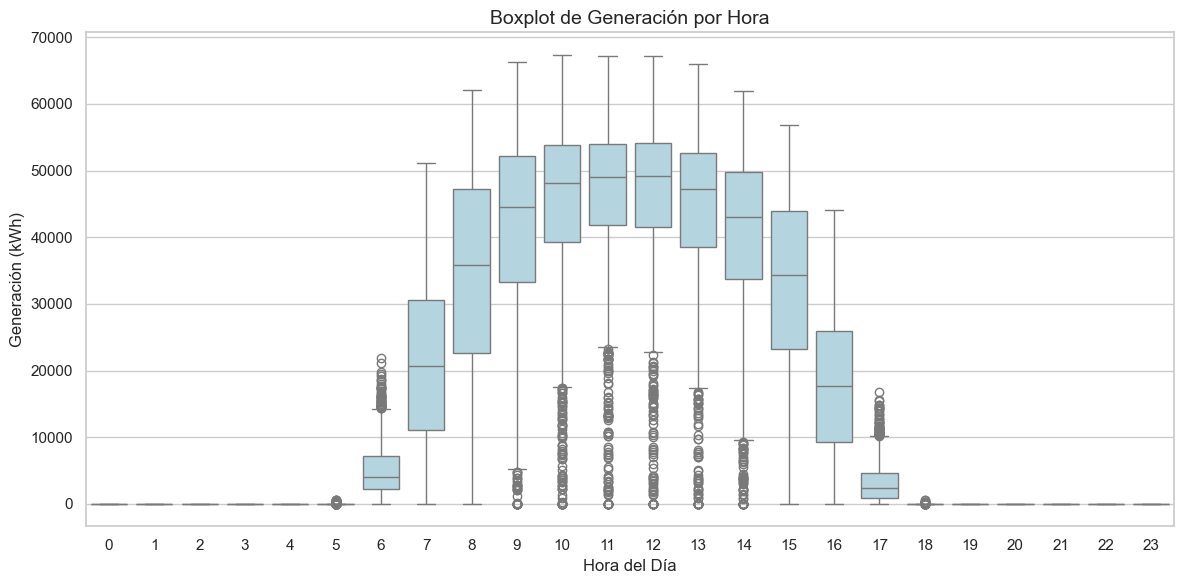

In [20]:
# Descarga de datos desde Google Drive y Análisis Exploratorio (EDA)
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

def download_file_from_google_drive(id, destination):
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={'id': id}, stream=True)
    token = None
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        params = {'id': id, 'confirm': token}
        response = session.get(URL, params=params, stream=True)
    
    with open(destination, "wb") as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)

file_id = '1XM7xrH4WCh1knxF7kTt9Mj3mx1RUGnWC'
destination = 'data/data_2019_2023_kwH_xm.csv'

if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists(destination):
    print("Descargando archivo desde Google Drive...")
    download_file_from_google_drive(file_id, destination)
    print("Descarga completada.")
else:
    print("El archivo de datos de XM ya existe localmente.")

# Cargar y preparar datos
df = pd.read_csv(destination)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='mixed')
hours = [str(i) for i in range(24)]
df_melted = df.melt(id_vars=['Fecha'], value_vars=hours, var_name='Hora', value_name='Generacion')
df_melted['Hora'] = df_melted['Hora'].astype(int)
df_melted['Timestamp'] = df_melted['Fecha'] + pd.to_timedelta(df_melted['Hora'], unit='h')
df_melted = df_melted.sort_values('Timestamp').reset_index(drop=True)

sns.set_theme(style="whitegrid")
print("Generando visualizaciones...")

# 1. Serie Temporal Completa (Horaria)
plt.figure(figsize=(15, 6))
plt.plot(df_melted['Timestamp'], df_melted['Generacion'], color='#1f77b4', linewidth=0.5, alpha=0.7)
plt.title('Serie Temporal Completa: Generación Horaria (kWh)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Generación (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Serie Temporal Mensual Total
df_monthly_sum = df_melted.set_index('Timestamp')['Generacion'].resample('ME').sum().reset_index()
plt.figure(figsize=(15, 6))
plt.plot(df_monthly_sum['Timestamp'], df_monthly_sum['Generacion'], marker='o', color="#e377c2", linewidth=2)
plt.title('Serie Temporal: Generación Total Mensual (kWh)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Generación Total (kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Heatmap Día vs Hora
heatmap_data = df.copy()
heatmap_data['Fecha_str'] = heatmap_data['Fecha'].dt.strftime('%Y-%m-%d')
heatmap_data = heatmap_data.set_index('Fecha_str')[hours].astype(float)
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Generación (kWh)'})
plt.title('Heatmap de Generación: Día vs Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Fecha', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Boxplot de Generación por Hora
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Hora', y='Generacion', color="lightblue")
plt.title('Boxplot de Generación por Hora', fontsize=14)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Generación (kWh)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis de las Visualizaciones de Generación (XM)

1. **Serie Temporal Completa**: Muestra la evolución horaria de la generación desde 2019 hasta 2023. Se observa la alternancia natural entre día y noche, así como la variabilidad interanual.
2. **Serie Temporal Mensual Total**: Al agregar los datos mensualmente, podemos identificar con mayor claridad la estacionalidad de la planta. Los picos de generación suelen coincidir con las épocas de mayor radiación solar en el departamento del Cesar.
3. **Heatmap Día vs Hora**: Esta visualización permite ver patrones de despacho. La franja central representa las horas de sol. Se puede notar cómo la intensidad varía según la época del año (estacionalidad vertical).
4. **Boxplot de Generación por Hora**: Representa la distribución de la energía generada en cada hora. Permite observar los valores máximos alcanzados al mediodía y la dispersión causada por factores climáticos 

### Fuentes Climáticas: NASA POWER vs Open-Meteo
Para el entrenamiento de los modelos, se evaluaron dos fuentes principales:

1. **Open-Meteo (ERA5/ERA5-Land)**: Proporciona datos de reanálisis de alta precisión
2. **NASA POWER**: Utiliza datos satelitales calibrados para energía renovable.

**¿Por qué se eligió NASA POWER?**
Aunque Open-Meteo es altamente preciso, se seleccionó **NASA POWER** como base principal para el dataset consolidado debido a que no presenta valores faltantes (nulls) en el rango de tiempo estudiado (2019-2023), lo que garantiza un entrenamiento estable sin necesidad de imputaciones complejas.

### Variables de NASA POWER Utilizadas:
| Variable API | Columna CSV | Unidad | Descripción |
| :--- | :--- | :--- | :--- |
| `ALLSKY_SFC_SW_DWN` | `Irradiancia_It` | Wh/m² | Irradiancia de onda corta hacia abajo (superficie). |
| `T2M` | `Temperatura_Tt` | °C | Temperatura a 2 metros. |
| `RH2M` | `Humedad_Ht` | % | Humedad relativa a 2 metros. |
| `WS10M` | `Viento_Wt` | km/h | Velocidad del viento a 10 metros. |

### Metodología de Procesamiento
Se aplica un **Filtro de Horas Diurnas**: Solo se conservan los registros entre las **06:00 AM y las 05:00 PM** (12 registros por día)

### Análisis de Correlación NASA-XM

--- Iniciando Análisis de Correlación NASA-XM ---


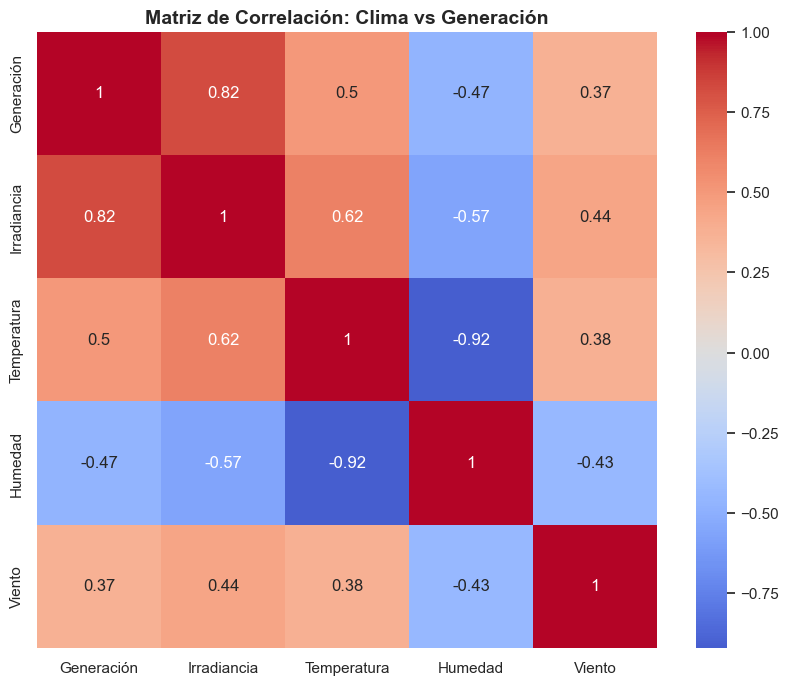

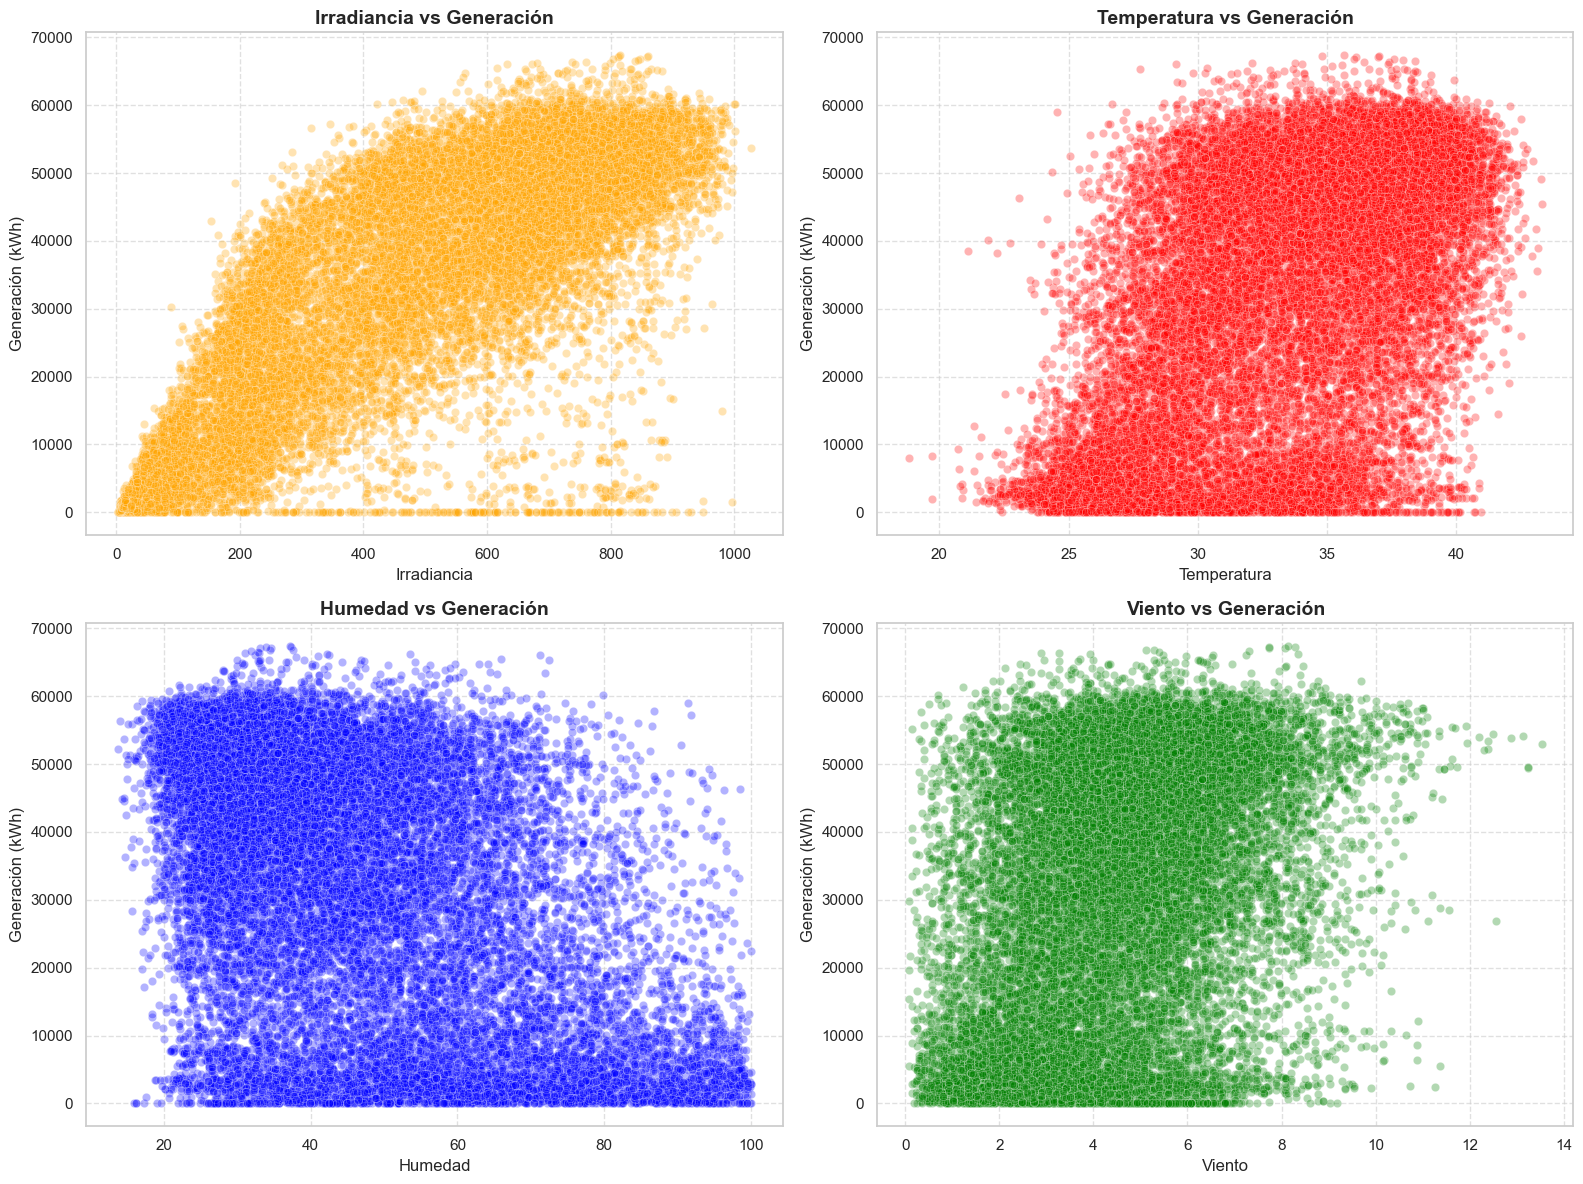

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Iniciando Análisis de Correlación NASA-XM ---")
data_path = 'data/data-hourly.csv'
output_dir = 'EDA/NASA_xm_correlation'
os.makedirs(output_dir, exist_ok=True)

df_corr_raw = pd.read_csv(data_path)
# Mapeo de nombres para visualización
cols_map = {
    'kWh': 'Generación', 
    'Irradiancia_It': 'Irradiancia', 
    'Temperatura_Tt': 'Temperatura', 
    'Humedad_Ht': 'Humedad', 
    'Viento_Wt': 'Viento'
}
df_corr = df_corr_raw[list(cols_map.keys())].rename(columns=cols_map)

sns.set_theme(style="whitegrid")

# 1. Matriz de Correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title('Matriz de Correlación: Clima vs Generación', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(output_dir, '1_1_heatmap_correlacion.png'))
plt.show()

# 2. Scatter Plots: Variables Climáticas vs Generación
climatic_vars = ['Irradiancia_It', 'Temperatura_Tt', 'Humedad_Ht', 'Viento_Wt']
colors = ['orange', 'red', 'blue', 'green']
titles = ['Irradiancia vs Generación', 'Temperatura vs Generación', 'Humedad vs Generación', 'Viento vs Generación']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(climatic_vars):
    sns.scatterplot(data=df_corr_raw, x=var, y='kWh', alpha=0.3, color=colors[i], ax=axes[i])
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel(cols_map[var], fontsize=12)
    axes[i].set_ylabel('Generación (kWh)', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scatter_climatic_vars_vs_generacion.png'))
plt.show()

### Selección de Variables: Eliminación de Humedad

Tras analizar la matriz de correlación y los scatter plots, se observa que la **Humedad (`Humedad_Ht`)** presenta una correlación inversa con la generación, pero su aporte al modelo puede ser redundante debido a la **multicolinealidad** con la temperatura. 

Para mejorar la robustez del modelo y reducir la dimensionalidad innecesaria, se ha decidido **eliminar la variable de Humedad** de los datasets de entrenamiento.

### Consolidación de Datasets: Horario y Mensual

Tras el procesamiento de los datos de generación y clima, se han generado dos datasets principales para el modelado:

1. **Dataset Horario (`data-hourly.csv`)**: Contiene las variables climáticas (Irradiancia, Temperatura, Humedad, Viento) alineadas con la generación real de energía en el rango de 06:00 AM a 05:00 PM.
2. **Dataset Mensual (`monthly-data.csv`)**: Agrega la información a nivel mensual, calculando el promedio (`mean`) y la desviación estándar (`std`) de las variables climáticas, junto con la generación total mensual (`sum`).

In [26]:
# Descarga de datasets consolidados desde Google Drive
import os
import pandas as pd
import requests

def download_file_from_google_drive(id, destination):
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={'id': id}, stream=True)
    token = None
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        params = {'id': id, 'confirm': token}
        response = session.get(URL, params=params, stream=True)
    
    with open(destination, "wb") as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)

ids = {
    'data/data-hourly.csv': '1kQ9LkdU5A-Y5ji5u5eetrdQ0yCCRz8jX',
    'data/monthly-data.csv': '1XopE0Y_QqrAFT9_sT0FyCqSQ0kidpbAS'
}

for dest, file_id in ids.items():
    if not os.path.exists(dest):
        download_file_from_google_drive(file_id, dest)

# Cargar y Filtrar Humedad
df_hourly = pd.read_csv('data/data-hourly.csv')
df_monthly = pd.read_csv('data/monthly-data.csv')

cols_to_drop_hourly = ['Humedad_Ht']
cols_to_drop_monthly = ['Humedad_Ht_mean', 'Humedad_Ht_std']

df_hourly = df_hourly.drop(columns=[c for c in cols_to_drop_hourly if c in df_hourly.columns])
df_monthly = df_monthly.drop(columns=[c for c in cols_to_drop_monthly if c in df_monthly.columns])

print("--- Dataset Horario (Head) - Humedad Eliminada ---")
display(df_hourly.head())

print("\n--- Dataset Mensual (Head) - Humedad Eliminada ---")
display(df_monthly.head())

--- Dataset Horario (Head) - Humedad Eliminada ---


,Fecha_Hora,Irradiancia_It,Temperatura_Tt,Viento_Wt,kWh
0,2019-01-01 06:00:00,32.90,25.06,8.784,400.0
1,2019-01-01 07:00:00,240.93,27.67,9.504,2900.0
2,2019-01-01 08:00:00,478.05,30.71,10.872,6400.0
3,2019-01-01 09:00:00,672.83,33.35,10.872,8600.0
4,2019-01-01 10:00:00,810.33,35.38,10.656,10100.0



--- Dataset Mensual (Head) - Humedad Eliminada ---


,Mes,Irradiancia_It_mean,Irradiancia_It_std,Temperatura_Tt_mean,Temperatura_Tt_std,Viento_Wt_mean,Viento_Wt_std,kWh_Total
0,2019-01,472.534375,290.800136,34.979271,4.470300,5.619625,2.358131,2139572.66
1,2019-02,475.651399,289.917855,35.534048,4.329122,5.840679,2.031040,4486629.63
2,2019-03,437.762500,269.932731,35.816048,3.975914,5.206839,2.113897,9895324.82
3,2019-04,441.678103,270.644109,34.427184,4.105325,4.853793,2.065013,11038504.26
4,2019-05,434.547876,258.763872,32.200699,4.308045,3.976355,1.899331,8813251.30


# Modelo estadistico: SARIMAX
### Análisis Estadístico de la Serie de Tiempo

Para determinar los parametros del modelado SARIMAX, validamos los supuestos estadísticos de la serie de tiempo. Este análisis incluye:
1. **Prueba de Estacionariedad (ADF)**: Para determinar si la serie requiere diferenciación (`d`).
2. **Descomposición Estacional**: Para visualizar los componentes de tendencia, estacionalidad y residuo.
3. **Gráficos de Autocorrelación (ACF/PACF)**: Para identificar los órdenes potenciales del modelo (`p`, `q`, `P`, `Q`).

--- Resultados de la Prueba de Dickey-Fuller Aumentada (ADF) ---
Estadístico ADF       -1.056289e+01
p-value                7.647240e-19
# Lags                 4.700000e+01
Obs                    2.168400e+04
Valor Crítico (1%)    -3.430652e+00
Valor Crítico (5%)    -2.861673e+00
Valor Crítico (10%)   -2.566841e+00
dtype: float64

Conclusión: La serie ES ESTACIONARIA (p <= 0.05)
Generando gráficos ACF y PACF...


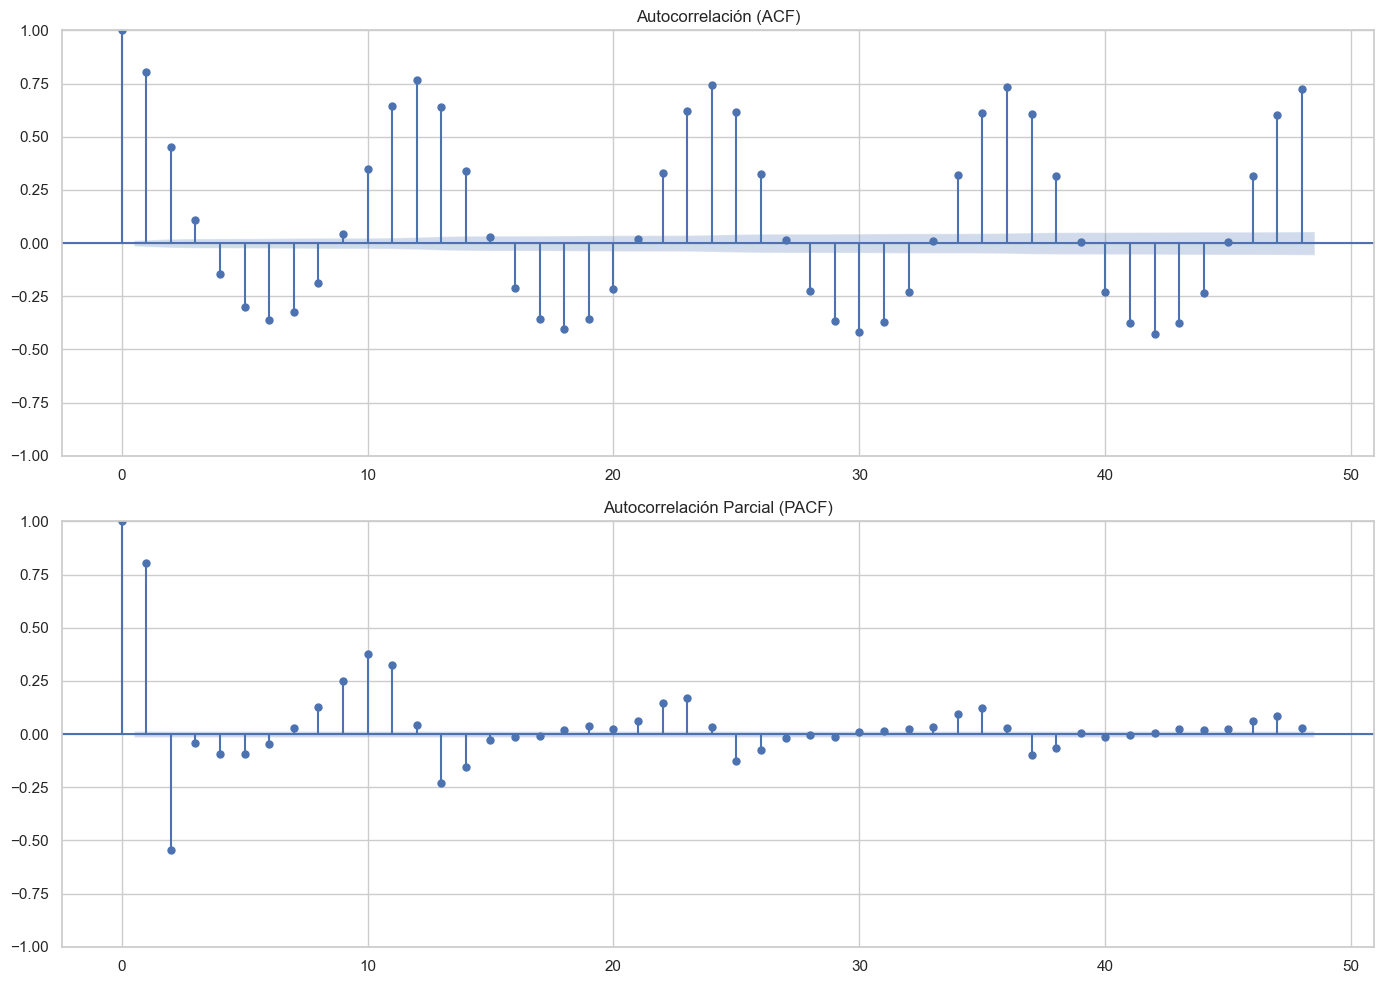

In [30]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

def check_stationarity(timeseries):
    print("--- Resultados de la Prueba de Dickey-Fuller Aumentada (ADF) ---")
    adf_test = adfuller(timeseries, autolag='AIC')
    adf_output = pd.Series(adf_test[0:4], index=['Estadístico ADF', 'p-value', '# Lags', 'Obs'])
    for key, value in adfuller(timeseries)[4].items():
        adf_output[f'Valor Crítico ({key})'] = value
    print(adf_output)
    if adf_test[1] <= 0.05:
        print("\nConclusión: La serie ES ESTACIONARIA (p <= 0.05)")
    else:
        print("\nConclusión: La serie NO ES ESTACIONARIA (p > 0.05)")

# Configuración
periodo_estacional = 12 # 12 horas operativas por día
ts = df_hourly['kWh'].values

# 1. Prueba de Estacionariedad
check_stationarity(ts)

# 2. ACF y PACF
print("Generando gráficos ACF y PACF...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
plot_acf(ts, lags=48, ax=ax1, title='Autocorrelación (ACF)')
plot_pacf(ts, lags=48, ax=ax2, title='Autocorrelación Parcial (PACF)')
plt.tight_layout()
plt.show()

### Justificación de Parámetros SARIMAX (2,0,1)(1,1,1)₁₂

A partir del análisis estadístico (ADF, ACF, PACF), se justifica la elección de los parámetros de la siguiente manera:

| Parámetro | Valor | Razón |
| :--- | :--- | :--- |
| **p** | 2 | PACF tiene lags 1 y 2 significativos (el 2 negativo pero grande). |
| **d** | 0 | ADF confirmó que la serie ES estacionaria. |
| **q** | 1 | ACF cae después del lag 1-2. |
| **P** | 1 | PACF tiene pico en zona del lag 10-11. |
| **D** | 1 | Los picos estacionales se repiten fuerte en ACF. |
| **Q** | 1 | ACF tiene pico en zona del lag 10-11. |
| **m** | 12 | 12 horas operativas por día (Estacionalidad diaria). |